In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from scipy.sparse import hstack


# Data Loading

In [3]:
df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [4]:
print(f"Train shape : {df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"Sample shape: {sample_df.shape}")

Train shape : (198000, 15)
Test shape  : (102000, 14)
Sample shape: (102000, 2)


# Milestone 1 related questions

In [5]:
#print(df.shape)
#df.head()

In [6]:
#print(test_df.shape)
#test_df.head()

In [7]:
#df.dtypes

In [8]:
#df.info

How many columns in the training dataset have object data type?

In [9]:
#object_cols = df.select_dtypes(include='object').shape[1]
#object_cols

How many numerical columns are present in the training dataset?

In [10]:
#numerical_cols = df.select_dtypes(include='int64').shape[1]
#numerical_cols

Which of the following columns is of boolean type?

In [11]:
#boolean_cols = df.select_dtypes(include='bool').head()
#boolean_cols

Which of the following columns have missing values?

In [12]:
#missing_cols = df.columns[df.isnull().any()]
#missing_cols

In [13]:
#df.isna().sum()


How many distinct target classes are present in the dataset?

In [14]:
#num_classes = df["label"].nunique()
#num_classes

In [15]:
#print(df["label"].value_counts())


What percentage of the dataset approximately belongs to label 0?

In [16]:
#total = len(df)
#label_0_count = (df["label"] == 0).sum()
#percentage = (label_0_count / total) * 100
#percentage

What is the median number of upvotes per comment?

In [17]:
#median_upvotes = df["upvote"].median()
#median_upvotes

Which numerical feature shows the largest maximum value?

In [18]:
#num_cols = df.select_dtypes(include=['int64', 'float64'])
#max_values = num_cols.max()

#largest_feature = max_values.idxmax()
#largest_value = max_values.max()

#print("Feature with largest max value:", largest_feature)
#print("Largest max value:", largest_value)

What is the minimum value of if_2?

In [19]:
#minimum_value_if_2 = df["if_2"].min()
#print("Minimum value of if_2: ", minimum_value_if_2)


In [20]:
#print(df["religion"].value_counts())

In [21]:
#df.describe()


In [22]:
#df["label"].value_counts()


In [23]:
#df["label"].value_counts(normalize=True) * 100


# Exploratory Data Analysis
Data visualization


Statistical analysis

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [25]:
df.isnull().sum().sort_values(ascending=False)

gender          145423
race            145423
religion        145423
comment              1
created_date         0
post_id              0
emoticon_1           0
downvote             0
upvote               0
emoticon_3           0
emoticon_2           0
if_1                 0
if_2                 0
disability           0
label                0
dtype: int64

In [26]:
import matplotlib.pyplot as plt

df["label"].value_counts()
df["label"].value_counts(normalize=True)

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64

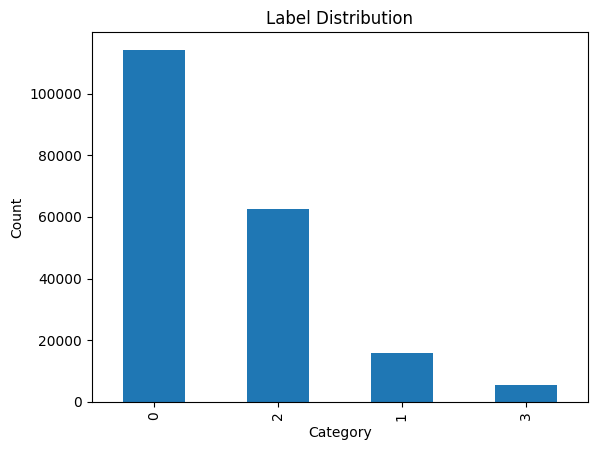

In [27]:
df["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [28]:
df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [29]:
df["engagement_score"] = df["upvote"] - df["downvote"]

In [30]:
df.groupby("label")["engagement_score"].mean()

label
0    1.829539
1    2.048059
2    2.156102
3    1.521485
Name: engagement_score, dtype: float64

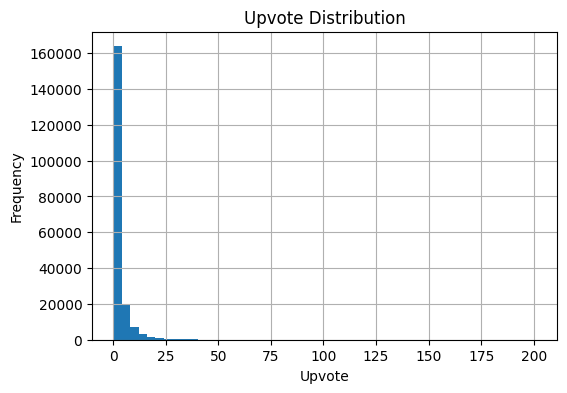

In [31]:
plt.figure(figsize=(6,4))
df["upvote"].hist(bins=50)
plt.title("Upvote Distribution")
plt.xlabel("Upvote")
plt.ylabel("Frequency")
plt.show()

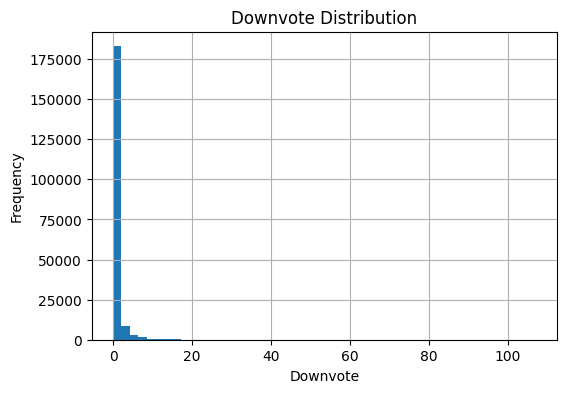

In [32]:
plt.figure(figsize=(6,4))
df["downvote"].hist(bins=50)
plt.title("Downvote Distribution")
plt.xlabel("Downvote")
plt.ylabel("Frequency")
plt.show()

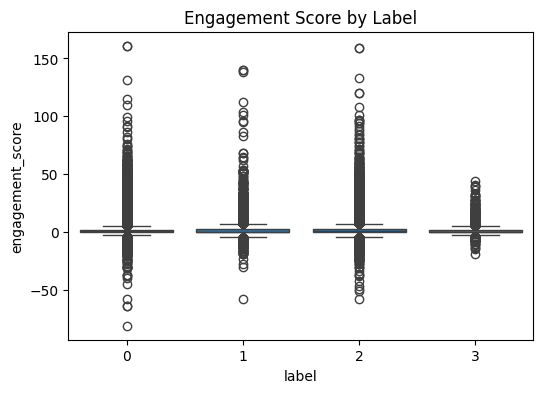

In [33]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="engagement_score", data=df)
plt.title("Engagement Score by Label")
plt.show()

In [34]:
df["comment_length"] = df["comment"].astype(str).apply(len)

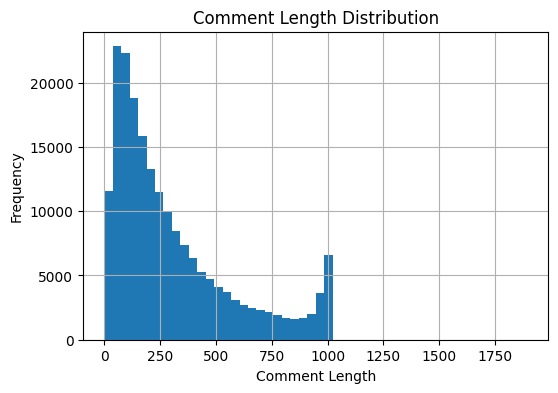

In [35]:
plt.figure(figsize=(6,4))
df["comment_length"].hist(bins=50)
plt.title("Comment Length Distribution")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.show()

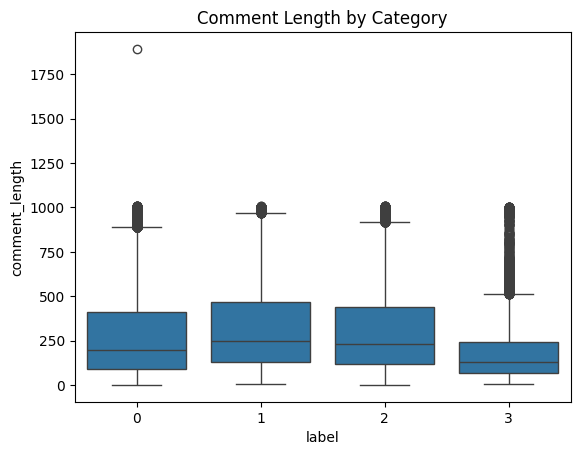

In [36]:
sns.boxplot(x="label", y="comment_length", data=df)
plt.title("Comment Length by Category")
plt.show()

In [37]:
pd.crosstab(df["race"], df["label"])
pd.crosstab(df["religion"], df["label"])
pd.crosstab(df["gender"], df["label"])
pd.crosstab(df["disability"], df["label"])

label,0,1,2,3
disability,,,,
False,113311,15494,61043,5409
True,862,424,1397,60


In [38]:
df["created_date"] = pd.to_datetime(df["created_date"])

df["hour"] = df["created_date"].dt.hour
df["day_of_week"] = df["created_date"].dt.dayofweek

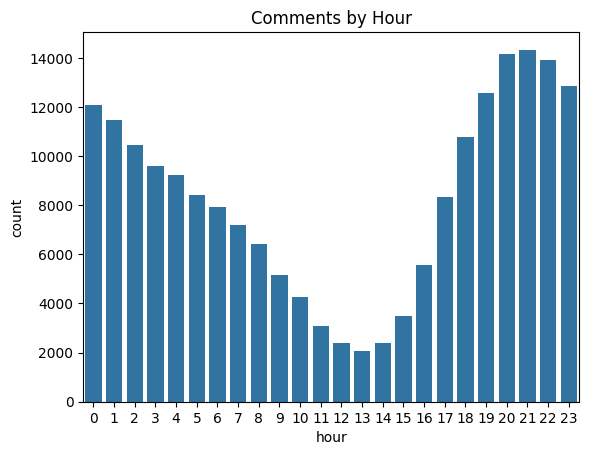

In [39]:
sns.countplot(x="hour", data=df)
plt.title("Comments by Hour")
plt.show()

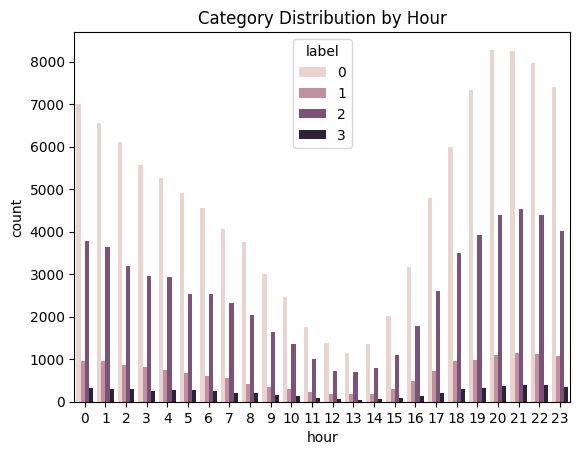

In [40]:
sns.countplot(x="hour", hue="label", data=df)
plt.title("Category Distribution by Hour")
plt.show()

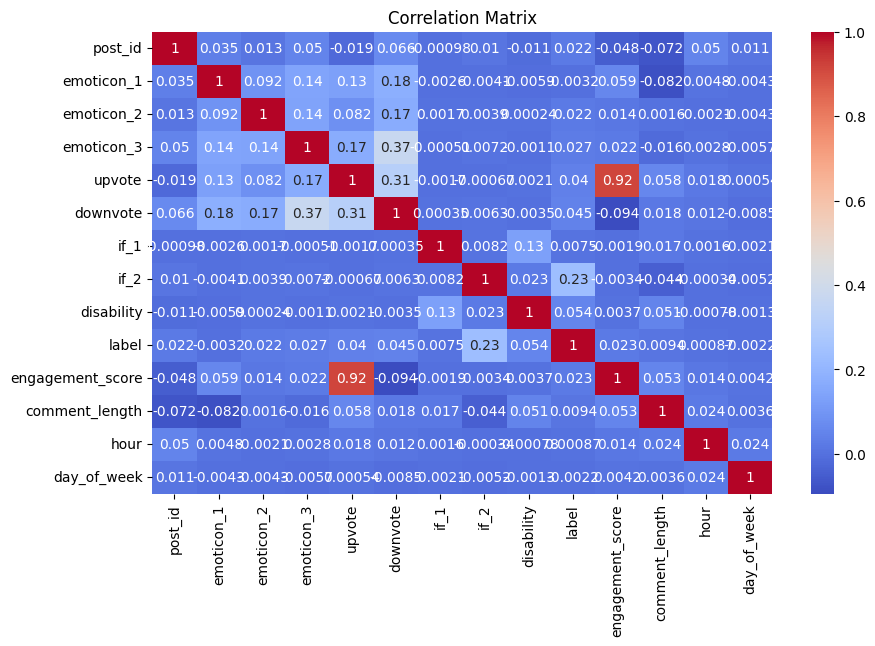

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [42]:
from scipy.stats import f_oneway

groups = [df[df["label"] == i]["engagement_score"] for i in df["label"].unique()]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(78.3323043796592), pvalue=np.float64(1.2313425830290032e-50))

# Data Cleaning/ Preprocessing

In [43]:

import numpy as np
import re

df["race"] = df["race"].notnull().astype(int)
df["religion"] = df["religion"].notnull().astype(int)
df["gender"] = df["gender"].notnull().astype(int)

df["comment"] = df["comment"].fillna("")

df["created_date"] = pd.to_datetime(df["created_date"])

df["hour"] = df["created_date"].dt.hour
df["day_of_week"] = df["created_date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df.drop("created_date", axis=1, inplace=True)

df["comment_length"] = df["comment"].apply(len)

df["engagement_score"] = df["upvote"] - df["downvote"]

df["upvote"] = np.log1p(df["upvote"])
df["downvote"] = np.log1p(df["downvote"])
df["if_1"] = np.log1p(df["if_1"])
df["if_2"] = np.log1p(df["if_2"])


def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["comment"] = df["comment"].apply(clean_text)

In [44]:

df["word_count"]    = df["comment"].apply(lambda x: len(str(x).split()))
df["unique_words"]  = df["comment"].apply(lambda x: len(set(str(x).split())))
df["caps_ratio"]    = df["comment"].apply(
    lambda x: sum(c.isupper() for c in str(x)) / (len(str(x)) + 1)
)
df["punct_count"]   = df["comment"].apply(
    lambda x: sum(1 for c in str(x) if c in "!?.,;:")
)

df["vote_ratio"]    = (df["upvote"] + 1) / (df["downvote"] + 1)
df["total_votes"]   = df["upvote"] + df["downvote"]

df["emoticon_sum"]  = df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"]
df["identity_flag"] = (
    df["race"] + df["religion"] + df["gender"] +
    df["disability"].astype(int)
)
print("Score Boost A: extra features added to df.")
print("New df shape:", df.shape)


Score Boost A: extra features added to df.
New df shape: (198000, 27)


In [45]:

X = df.drop("label", axis=1)
y = df["label"]

In [46]:


text_feature = "comment"

numeric_features = [
    "upvote",
    "downvote",
    "if_1",
    "if_2",
    "engagement_score",
    "comment_length",
    "hour"
]

binary_features = [
    "emoticon_1",
    "emoticon_2",
    "emoticon_3",
    "race",
    "religion",
    "gender",
    "disability",
    "is_weekend"
]

# Train-Validation Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,          # 80-20 split
    stratify=y,             # preserves class ratio
    random_state=42
)

In [48]:
print("Train Distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation Distribution:")
print(y_val.value_counts(normalize=True))

Train Distribution:
label
0    0.576629
2    0.315354
1    0.080398
3    0.027620
Name: proportion, dtype: float64

Validation Distribution:
label
0    0.576641
2    0.315354
1    0.080379
3    0.027626
Name: proportion, dtype: float64


In [49]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [50]:

from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [51]:


from sklearn.feature_extraction.text import TfidfVectorizer

text_transformer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=3,
    sublinear_tf=True,
    strip_accents="unicode"
)

In [52]:

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_transformer, text_feature),
        ("num", numeric_transformer, numeric_features),
        ("bin", "passthrough", binary_features)
    ]
)

# Building a baseline model. 

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [55]:
from sklearn.preprocessing import MinMaxScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=10000,
            ngram_range=(1,2),
            min_df=3
        ), text_feature),

        ("num", MinMaxScaler(), numeric_features), 

        ("bin", "passthrough", binary_features)
    ]
)

In [56]:
model = Pipeline([
    ("features", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [57]:
model.fit(X_train, y_train)

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'comment'),
                                                 ('num', MinMaxScaler(),
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'engagement_score',
                                                   'comment_length', 'hour']),
                                                 ('bin', 'passthrough',
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'race',
                                                   'religion', 'gender',
                                                   'disability',
                                                   'is_weekend'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1))])

In [58]:

import numpy as np
from lightgbm import LGBMClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix

RICH_NUM = [
    "upvote", "downvote", "if_1", "if_2",
    "engagement_score", "comment_length", "hour", "day_of_week",
    "word_count", "unique_words", "caps_ratio",
    "punct_count", "vote_ratio", "total_votes",
]
RICH_BIN = [
    "emoticon_1", "emoticon_2", "emoticon_3",
    "race", "religion", "gender", "disability",
    "is_weekend", "emoticon_sum", "identity_flag",
]

X2  = df.drop("label", axis=1)
y2  = df["label"]
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

tfidf_sb   = TfidfVectorizer(
    max_features=25000, ngram_range=(1, 2),
    min_df=3, sublinear_tf=True,
    strip_accents="unicode", analyzer="word"
)
imputer_sb = SimpleImputer(strategy="median")
scaler_sb  = StandardScaler(with_mean=False)

Xtr_w = tfidf_sb.fit_transform(X2_train["comment"])
Xv_w  = tfidf_sb.transform(X2_val["comment"])
Xtr_n = csr_matrix(scaler_sb.fit_transform(
    imputer_sb.fit_transform(X2_train[RICH_NUM])
))
Xv_n  = csr_matrix(scaler_sb.transform(
    imputer_sb.transform(X2_val[RICH_NUM])
))
Xtr_b = csr_matrix(X2_train[RICH_BIN].fillna(0).values.astype(float))
Xv_b  = csr_matrix(X2_val[RICH_BIN].fillna(0).values.astype(float))

Xtr_feat = hstack([Xtr_w, Xtr_n, Xtr_b])
Xv_feat  = hstack([Xv_w,  Xv_n,  Xv_b])
print(f"Train matrix: {Xtr_feat.shape}")
print(f"Val   matrix: {Xv_feat.shape}")

lgbm_sb = LGBMClassifier(
    n_estimators=800, learning_rate=0.05, num_leaves=127,
    max_depth=-1, min_child_samples=20,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    class_weight="balanced",
    n_jobs=-1, random_state=42, verbose=-1,
)
lgbm_sb.fit(Xtr_feat, y2_train)
lgbm_preds = lgbm_sb.predict(Xv_feat)
print(f"\nLightGBM  Val Acc: {accuracy_score(y2_val, lgbm_preds):.5f}")
print(f"LightGBM  Val F1 : {f1_score(y2_val, lgbm_preds, average='macro'):.5f}")


Train matrix: (158400, 25024)
Val   matrix: (39600, 25024)

LightGBM  Val Acc: 0.91366
LightGBM  Val F1 : 0.81823


In [59]:


from xgboost import XGBClassifier

xgb_sb = XGBClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric="mlogloss", tree_method="hist",
    n_jobs=-1, random_state=42, verbosity=0,
)
xgb_sb.fit(Xtr_feat, y2_train)
xgb_preds = xgb_sb.predict(Xv_feat)
print(f"XGBoost   Val Acc: {accuracy_score(y2_val, xgb_preds):.5f}")
print(f"XGBoost   Val F1 : {f1_score(y2_val, xgb_preds, average='macro'):.5f}")


XGBoost   Val Acc: 0.90838
XGBoost   Val F1 : 0.78365


In [60]:

from sklearn.linear_model import LogisticRegression

lr_sb = LogisticRegression(
    C=3.0, max_iter=1000, solver="saga",
    multi_class="multinomial", n_jobs=-1, random_state=42,
)
lr_sb.fit(Xtr_feat, y2_train)
lr_preds = lr_sb.predict(Xv_feat)
print(f"LogReg    Val Acc: {accuracy_score(y2_val, lr_preds):.5f}")
print(f"LogReg    Val F1 : {f1_score(y2_val, lr_preds, average='macro'):.5f}")


LogReg    Val Acc: 0.89891
LogReg    Val F1 : 0.76857


In [61]:

import numpy as np

p_lgbm = lgbm_sb.predict_proba(Xv_feat)
p_xgb  = xgb_sb.predict_proba(Xv_feat)
p_lr   = lr_sb.predict_proba(Xv_feat)

best_acc, best_w = 0, (0.5, 0.3, 0.2)
for wl in np.arange(0.35, 0.56, 0.05):
    for wx in np.arange(0.25, 0.46, 0.05):
        wlr = round(1.0 - wl - wx, 2)
        if wlr <= 0:
            continue
        proba = wl*p_lgbm + wx*p_xgb + wlr*p_lr
        acc   = accuracy_score(y2_val, np.argmax(proba, axis=1))
        if acc > best_acc:
            best_acc = acc
            best_w   = (round(float(wl),2), round(float(wx),2), wlr)

wl, wx, wlr = best_w
ens_preds = np.argmax(wl*p_lgbm + wx*p_xgb + wlr*p_lr, axis=1)
print(f"Best weights  : LGBM={wl}, XGB={wx}, LR={wlr}")
print(f"Ensemble Val Acc: {accuracy_score(y2_val, ens_preds):.5f}")
print(f"Ensemble Val F1 : {f1_score(y2_val, ens_preds, average='macro'):.5f}")
print("\nClassification Report:")
print(classification_report(y2_val, ens_preds))


Best weights  : LGBM=0.5, XGB=0.25, LR=0.25
Ensemble Val Acc: 0.91568
Ensemble Val F1 : 0.81930

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.77      0.79      0.78      3183
           2       0.86      0.92      0.89     12488
           3       0.73      0.58      0.65      1094

    accuracy                           0.92     39600
   macro avg       0.83      0.81      0.82     39600
weighted avg       0.92      0.92      0.92     39600



In [62]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1 Macro:", f1_score(y_val, y_pred, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

Accuracy: 0.8864646464646465
F1 Macro: 0.7714509984776784

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.65      0.83      0.73      3183
           2       0.88      0.83      0.85     12488
           3       0.43      0.77      0.55      1094

    accuracy                           0.89     39600
   macro avg       0.73      0.84      0.77     39600
weighted avg       0.90      0.89      0.89     39600



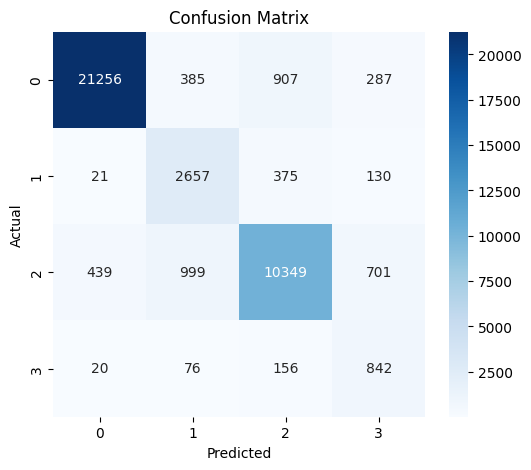

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Linear Models

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("features", preprocessor),
    ("clf", LogisticRegression(
        C=1.0,
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'comment'),
                                                 ('num', MinMaxScaler(),
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'engagement_score',
                                                   'comment_length', 'hour']),
                                                 ('bin', 'passthrough',
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'race',
                                                   'religion', 'gender',
                                                   'disability',
                                                   'is_weekend'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1))])

In [65]:
from sklearn.metrics import f1_score

lr_pred = lr_model.predict(X_val)

print("Logistic Regression F1 Macro:",
      f1_score(y_val, lr_pred, average="macro"))

Logistic Regression F1 Macro: 0.7714509984776784


In [66]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ("features", preprocessor),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced"
    ))
])

svm_model.fit(X_train, y_train)

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'comment'),
                                                 ('num', MinMaxScaler(),
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'engagement_score',
                                                   'comment_length', 'hour']),
                                                 ('bin', 'passthrough',
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'race',
                                                   'religion', 'gender',
                                                   'disability',
                                                   'is_weekend'])])),
                ('clf', LinearSVC(class_weight='balanced'))])

In [67]:
svm_pred = svm_model.predict(X_val)

print("Linear SVM F1 Macro:",
      f1_score(y_val, svm_pred, average="macro"))

Linear SVM F1 Macro: 0.7772080580112599


In [68]:
from sklearn.linear_model import SGDClassifier

sgd_model = Pipeline([
    ("features", preprocessor),
    ("clf", SGDClassifier(
        loss="log_loss",   
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

sgd_model.fit(X_train, y_train)

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'comment'),
                                                 ('num', MinMaxScaler(),
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'engagement_score',
                                                   'comment_length', 'hour']),
                                                 ('bin', 'passthrough',
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'race',
                                                   'religion', 'gender',
                                                   'disability',
                                                   'is_weekend'])])),
                ('clf',
                 SGDClassifier(class_weight='balanced', loss='log_loss',
                               max_iter=2000, random_state=42))])

In [69]:
sgd_pred = sgd_model.predict(X_val)

print("SGD Classifier F1 Macro:",
      f1_score(y_val, sgd_pred, average="macro"))

SGD Classifier F1 Macro: 0.7676934689443923


In [70]:
print("LR  :", f1_score(y_val, lr_pred, average="macro"))
print("SVM :", f1_score(y_val, svm_pred, average="macro"))
print("SGD :", f1_score(y_val, sgd_pred, average="macro"))

LR  : 0.7714509984776784
SVM : 0.7772080580112599
SGD : 0.7676934689443923


In [71]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline

sgd_pipeline = Pipeline([
    ("features", preprocessor),
    ("clf", SGDClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

In [72]:
param_grid = {
    "clf__loss": ["log_loss", "hinge"],   
    "clf__alpha": [1e-4, 1e-3, 1e-2],     
    "clf__penalty": ["l2", "l1"],
    "clf__max_iter": [1000, 2000]
}

In [73]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    sgd_pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",   
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('features',
                                        ColumnTransformer(transformers=[('text',
                                                                         TfidfVectorizer(max_features=10000,
                                                                                         min_df=3,
                                                                                         ngram_range=(1,
                                                                                                      2)),
                                                                         'comment'),
                                                                        ('num',
                                                                         MinMaxScaler(),
                                                                         ['upvote',
                                                                          'downvote',
                                                                          'if_1',
                                                                          'if_2',
                                                                          'engagement_score',
                                                                          'comment_length',
                                                                          'hour']),
                                                                        ('bin',
                                                                         'passthrough',
                                                                         ['emoticon_1',
                                                                          'emoticon_2',
                                                                          'emoticon_3',
                                                                          'race',
                                                                          'religion',
                                                                          'gender',
                                                                          'disability',
                                                                          'is_weekend'])])),
                                       ('clf',
                                        SGDClassifier(class_weight='balanced',
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__alpha': [0.0001, 0.001, 0.01],
                         'clf__loss': ['log_loss', 'hinge'],
                         'clf__max_iter': [1000, 2000],
                         'clf__penalty': ['l2', 'l1']},
             scoring='f1_macro', verbose=1)

In [74]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'clf__alpha': 0.0001, 'clf__loss': 'hinge', 'clf__max_iter': 1000, 'clf__penalty': 'l2'}
Best CV Score:
0.7767977284440993


In [75]:
best_sgd = grid_search.best_estimator_

y_pred = best_sgd.predict(X_val)

from sklearn.metrics import classification_report, f1_score

print("Validation F1 Macro:",
      f1_score(y_val, y_pred, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

Validation F1 Macro: 0.7749632711437597

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.94      0.95     22835
           1       0.69      0.77      0.73      3183
           2       0.84      0.88      0.86     12488
           3       0.65      0.49      0.56      1094

    accuracy                           0.89     39600
   macro avg       0.79      0.77      0.77     39600
weighted avg       0.90      0.89      0.89     39600



# Milestone 2

q1

In [76]:
#df["comment"].isnull()

q2

In [77]:
#import pandas as pd

#df_raw = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

#df_raw["created_date"] = pd.to_datetime(df_raw["created_date"])

#df_raw["month"] = df_raw["created_date"].dt.month_name()

#most_common_month = df_raw["month"].value_counts().idxmax()

#print(most_common_month.lower())

q3

In [78]:
# Create new feature
#df_raw["total_emoticons"] = (
#    df_raw["emoticon_1"] +
#    df_raw["emoticon_2"] +
#    df_raw["emoticon_3"]
#)

#max_value = df_raw["total_emoticons"].max()

#print(max_value)

q4

In [79]:

#df_raw["comment"] = df_raw["comment"].fillna("")

#label_3_comments = df_raw[df_raw["label"] == 3]["comment"]

#lengths = label_3_comments.apply(len)

#median_length = lengths.median()

#print(median_length)

q5

In [80]:
#min_upvote = df_raw["upvote"].min()
#max_upvote = df_raw["upvote"].max()

#print("Min:", min_upvote)
#print("Max:", max_upvote)

In [81]:
#scaled_value = (10 - min_upvote) / (max_upvote - min_upvote)

#print(scaled_value)

q6

In [82]:

#df_raw["comment"] = df_raw["comment"].fillna("")

#label_1_comments = df_raw[df_raw["label"] == 1]["comment"]

#word_counts = label_1_comments.apply(lambda x: len(x.split()))

#average_word_count = round(word_counts.mean(), 2)

#print(average_word_count)

q7

In [83]:

#df_raw["comment"] = df_raw["comment"].fillna("")

#count_trump = df_raw["comment"].str.contains("trump", case=False, regex=False).sum()

#print(count_trump)

q8

In [84]:
#import re
#import string

#stop_words = [
#    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at',
#    'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out',
#    'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
#    'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them',
#    'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which',
#    'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your'
#]

#text = df_raw.loc[0, "comment"]

#if pd.isna(text):
#    text = ""

#text = text.lower()

#text = text.translate(str.maketrans('', '', string.punctuation))

#words = text.split()

#filtered_words = [word for word in words if word not in stop_words]

#print(len(filtered_words))

q9

In [85]:
#df_raw["comment"] = df_raw["comment"].fillna("")

#lower_comments = df_raw["comment"].str.lower()

#all_tokens = []

#for text in lower_comments:
#    tokens = text.split()
#    all_tokens.extend(tokens)

#unique_token_count = len(set(all_tokens))

#print(unique_token_count)

q10

In [86]:
#from sklearn.feature_extraction.text import TfidfVectorizer

#df_raw["comment"] = df_raw["comment"].fillna("")

#vectorizer = TfidfVectorizer(
#    stop_words="english",
#    min_df=5,
#    ngram_range=(1, 2)
#)

#X_tfidf = vectorizer.fit_transform(df_raw["comment"])

#num_features = len(vectorizer.get_feature_names_out())

#print(num_features)

# Dimensionality Reduction (TruncatedSVD)

In [87]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

svd_model = Pipeline([
    ("features", preprocessor),
    ("svd", TruncatedSVD(n_components=300, random_state=42)),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

svd_model.fit(X_train, y_train)

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'comment'),
                                                 ('num', MinMaxScaler(),
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'engagement_score',
                                                   'comment_length', 'hour']),
                                                 ('bin', 'passthrough',
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'race',
                                                   'religion', 'gender',
                                                   'disability',
                                                   'is_weekend'])])),
                ('svd', TruncatedSVD(n_components=300, random_state=42)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [88]:
from sklearn.metrics import f1_score

svd_pred = svd_model.predict(X_val)
print("SVD + LR F1 Macro:", f1_score(y_val, svd_pred, average="macro"))

SVD + LR F1 Macro: 0.688478040337357


# Feature Selection (Chi-Square)

In [89]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression

fs_model = Pipeline([
    ("features", preprocessor),
    ("select", SelectKBest(chi2, k=8000)),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

fs_model.fit(X_train, y_train)

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'comment'),
                                                 ('num', MinMaxScaler(),
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'engagement_score',
                                                   'comment_length', 'hour']),
                                                 ('bin', 'passthrough',
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'race',
                                                   'religion', 'gender',
                                                   'disability',
                                                   'is_weekend'])])),
                ('select',
                 SelectKBest(k=8000,
                             score_func=<function chi2 at 0x7fae3a40ef20>)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [90]:
fs_pred = fs_model.predict(X_val)
print("Feature Selection + LR F1 Macro:",
      f1_score(y_val, fs_pred, average="macro"))

Feature Selection + LR F1 Macro: 0.7705361610583883


# Retrain Multiple Models

In [91]:
from sklearn.naive_bayes import MultinomialNB

nb_model = Pipeline([
    ("features", preprocessor),
    ("clf", MultinomialNB())
])

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_val)

print("Naive Bayes F1 Macro:",
      f1_score(y_val, nb_pred, average="macro"))

Naive Bayes F1 Macro: 0.49602215261370736


In [92]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("features", preprocessor),
    ("svd", TruncatedSVD(n_components=300, random_state=42)),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_val)

print("KNN F1 Macro:",
      f1_score(y_val, knn_pred, average="macro"))

KNN F1 Macro: 0.4080094809201772


In [93]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ("features", preprocessor),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced"
    ))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_val)

print("Linear SVM F1 Macro:",
      f1_score(y_val, svm_pred, average="macro"))

Linear SVM F1 Macro: 0.7772080580112599


In [94]:
print("SVD + LR :", f1_score(y_val, svd_pred, average="macro"))
print("FS + LR  :", f1_score(y_val, fs_pred, average="macro"))
print("NB       :", f1_score(y_val, nb_pred, average="macro"))
print("KNN      :", f1_score(y_val, knn_pred, average="macro"))
print("SVM      :", f1_score(y_val, svm_pred, average="macro"))

SVD + LR : 0.688478040337357
FS + LR  : 0.7705361610583883
NB       : 0.49602215261370736
KNN      : 0.4080094809201772
SVM      : 0.7772080580112599


# milestone 3

q1

In [95]:
#from sklearn.model_selection import train_test_split

#X = df.drop("label", axis=1)
#y = df["label"]

#X_train, X_val, y_train, y_val = train_test_split(
#    X,
#    y,
#    test_size=0.2,
#    random_state=42
#)

#a = X_train.shape[0]
#c = X_val.shape[0]

#print("a:", a)
#print("c:", c)
#print("a + c:", a + c)

q2

In [96]:
#import pandas as pd
#from sklearn.model_selection import train_test_split

#df_raw = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

#X = df_raw.drop("label", axis=1)
#y = df_raw["label"]

#X_train, X_val, y_train, y_val = train_test_split(
#    X,
#    y,
#    test_size=0.2,
#    random_state=42
#)

#X_train["created_date"] = pd.to_datetime(X_train["created_date"])

#X_train["month"] = X_train["created_date"].dt.month_name()

#most_common_month = X_train["month"].value_counts().idxmax()

#print(most_common_month.lower())

q3

In [97]:
#import pandas as pd
#from sklearn.preprocessing import OneHotEncoder

#categorical_cols = ["religion", "gender", "race"]

#X_train[categorical_cols] = X_train[categorical_cols].fillna("none")
#X_val[categorical_cols] = X_val[categorical_cols].fillna("none")

#encoder = OneHotEncoder(
#    handle_unknown="ignore",
#    sparse_output=False
#)

#encoded_train = encoder.fit_transform(X_train[categorical_cols])
#encoded_val = encoder.transform(X_val[categorical_cols])

#encoded_train_df = pd.DataFrame(
#    encoded_train,
 #   columns=encoder.get_feature_names_out(categorical_cols),
#    index=X_train.index
#)

#encoded_val_df = pd.DataFrame(
#    encoded_val,
#    columns=encoder.get_feature_names_out(categorical_cols),
#    index=X_val.index
#)

#X_train_final = X_train.drop(columns=categorical_cols)
#X_val_final = X_val.drop(columns=categorical_cols)

#X_train_final = pd.concat([X_train_final, encoded_train_df], axis=1)
#X_val_final = pd.concat([X_val_final, encoded_val_df], axis=1)

#a, b = X_train_final.shape

#print("Shape of X_train:", X_train_final.shape)
#print("Value of b:", b)

q4

In [98]:
#from sklearn.feature_extraction.text import CountVectorizer

#X_train["comment"] = X_train["comment"].fillna("")
#X_val["comment"] = X_val["comment"].fillna("")

#vectorizer = CountVectorizer()

#X_train_counts = vectorizer.fit_transform(X_train["comment"])

#X_val_counts = vectorizer.transform(X_val["comment"])

#doc_sum = X_train_counts[1].sum()

#print(doc_sum)

q5

In [99]:
# Convert disability to integer (True → 1, False → 0)
#X_train["disability"] = X_train["disability"].astype(int)
#X_val["disability"] = X_val["disability"].astype(int)

#total_sum = X_train["disability"].sum() + X_val["disability"].sum()

#print(total_sum)

q6

In [100]:
#from sklearn.preprocessing import StandardScaler

#if "created_date" in X_train.columns:
#    X_train = X_train.drop(columns=["created_date"])
#    X_val = X_val.drop(columns=["created_date"])

#numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

#scaler = StandardScaler()
#scaler.fit(X_train[numeric_cols])

#num_features_seen = scaler.n_features_in_

#print(num_features_seen)

q7

In [101]:
#import pandas as pd
#import numpy as np
#from sklearn.model_selection import train_test_split
#from sklearn.impute import SimpleImputer
#from sklearn.feature_extraction.text import TfidfVectorizer
#from sklearn.preprocessing import OneHotEncoder
#from sklearn.naive_bayes import MultinomialNB
#from sklearn.metrics import f1_score
##from scipy.sparse import hstack

##df_raw = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

#X = df_raw.drop("label", axis=1)
#y = df_raw["label"]

#X_train, X_val, y_train, y_val = train_test_split(
#    X, y,
 #   test_size=0.2,
#    random_state=42
#)

#imputer = SimpleImputer(strategy="most_frequent")

#X_train_imputed = pd.DataFrame(
#    imputer.fit_transform(X_train),
 #   columns=X_train.columns,
#    index=X_train.index
#)

#X_val_imputed = pd.DataFrame(
#    imputer.transform(X_val),
#    columns=X_val.columns,
#    index=X_val.index
#)

#X_train_imputed = X_train_imputed.applymap(
#    lambda x: abs(x) if isinstance(x, (int, float)) else x
#)

#X_val_imputed = X_val_imputed.applymap(
 #   lambda x: abs(x) if isinstance(x, (int, float)) else x
#)

#X_train_imputed["created_date"] = pd.to_datetime(X_train_imputed["created_date"])
#X_val_imputed["created_date"] = pd.to_datetime(X_val_imputed["created_date"])

#for df_temp in [X_train_imputed, X_val_imputed]:
#    df_temp["day"] = df_temp["created_date"].dt.day
#    df_temp["month"] = df_temp["created_date"].dt.month
#    df_temp["year"] = df_temp["created_date"].dt.year
#    df_temp.drop(columns=["created_date"], inplace=True)

#tfidf = TfidfVectorizer(stop_words="english")

#X_train_text = tfidf.fit_transform(X_train_imputed["comment"])
#X_val_text = tfidf.transform(X_val_imputed["comment"])

# Drop original comment column
#X_train_imputed = X_train_imputed.drop(columns=["comment"])
#X_val_imputed = X_val_imputed.drop(columns=["comment"])

#categorical_cols = X_train_imputed.select_dtypes(include=["object"]).columns

#encoder = OneHotEncoder(
#    handle_unknown="ignore",
#    sparse_output=True
#)

#X_train_cat = encoder.fit_transform(X_train_imputed[categorical_cols])
#X_val_cat = encoder.transform(X_val_imputed[categorical_cols])

#X_train_imputed = X_train_imputed.drop(columns=categorical_cols)
#X_val_imputed = X_val_imputed.drop(columns=categorical_cols)


#X_train_final = hstack([
#    X_train_text,
 #   X_train_cat,
#    X_train_imputed.values
##])

#X_val_final = hstack([
#    X_val_text,
#    X_val_cat,
#    X_val_imputed.values
##])

#nb = MultinomialNB()
#nb.fit(X_train_final, y_train)

#train_pred = nb.predict(X_train_final)

#train_f1_macro = f1_score(y_train, train_pred, average="macro")

#print("Macro F1 Score on Train:", train_f1_macro)

q8

In [102]:

#val_pred = nb.predict(X_val_final)

#val_f1_macro = f1_score(y_val, val_pred, average="macro")

#print("Macro F1 Score on Validation:", val_f1_macro)

q9

In [103]:
# import pandas as pd
#import numpy as np
#from sklearn.model_selection import train_test_split
#from sklearn.impute import SimpleImputer
#from sklearn.feature_extraction.text import TfidfVectorizer
#from sklearn.preprocessing import OneHotEncoder
#from sklearn.naive_bayes import MultinomialNB
#from sklearn.metrics import f1_score
#from scipy.sparse import hstack

#df_raw = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

#X = df_raw.drop("label", axis=1)
#y = df_raw["label"]

#X_train, X_val, y_train, y_val = train_test_split(
#    X, y,
#    test_size=0.2,
#    random_state=42
#)

#imputer = SimpleImputer(strategy="most_frequent")

#X_train = pd.DataFrame(
#    imputer.fit_transform(X_train),
#    columns=X_train.columns,
#    index=X_train.index
#)

#X_val = pd.DataFrame(
#    imputer.transform(X_val),
#    columns=X_val.columns,
#    index=X_val.index
#)

#X_train = X_train.applymap(
#    lambda x: abs(x) if isinstance(x, (int, float)) else x
#)
#X_val = X_val.applymap(
#    lambda x: abs(x) if isinstance(x, (int, float)) else x
#)

#X_train["created_date"] = pd.to_datetime(X_train["created_date"])
#X_val["created_date"] = pd.to_datetime(X_val["created_date"])

#for df_temp in [X_train, X_val]:
#    df_temp["day"] = df_temp["created_date"].dt.day
#    df_temp["month"] = df_temp["created_date"].dt.month
#    df_temp["year"] = df_temp["created_date"].dt.year
    
    # Create is_weekend
#    df_temp["is_weekend"] = (
#        df_temp["created_date"].dt.dayofweek >= 5
#    ).astype(int)
    
 #   df_temp.drop(columns=["created_date"], inplace=True)

#tfidf = TfidfVectorizer(stop_words="english")

#X_train_text = tfidf.fit_transform(X_train["comment"])
#X_val_text = tfidf.transform(X_val["comment"])

#X_train = X_train.drop(columns=["comment"])
#X_val = X_val.drop(columns=["comment"])

#categorical_cols = X_train.select_dtypes(include=["object"]).columns

#encoder = OneHotEncoder(
#    handle_unknown="ignore",
 #   sparse_output=True
#)

#X_train_cat = encoder.fit_transform(X_train[categorical_cols])
#X_val_cat = encoder.transform(X_val[categorical_cols])

#X_train = X_train.drop(columns=categorical_cols)
#X_val = X_val.drop(columns=categorical_cols)

#X_train_final = hstack([
#    X_train_text,
#    X_train_cat,
#    X_train.values
#])

#X_val_final = hstack([
#    X_val_text,
#    X_val_cat,
#    X_val.values
##])

#nb = MultinomialNB()
#nb.fit(X_train_final, y_train)

#train_pred = nb.predict(X_train_final)

#train_f1_macro = f1_score(y_train, train_pred, average="macro")

#print("Macro F1 (Train):", round(train_f1_macro, 4))

q10

In [104]:

#val_pred = nb.predict(X_val_final)

#val_f1_macro = f1_score(y_val, val_pred, average="macro")

#print("Macro F1 (Validation):", round(val_f1_macro, 4))

# Ensemble (Bagging, Boosting, Stacking) Multi-layer Perceptron

In [105]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

bagging_model = Pipeline([
    ("features", preprocessor),
    ("clf", BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ))
])

bagging_model.fit(X_train, y_train)

bag_pred = bagging_model.predict(X_val)

print("Bagging F1:", f1_score(y_val, bag_pred, average="macro"))

Bagging F1: 0.7666217252141924


In [106]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

boost_model = Pipeline([
    ("features", preprocessor),   # converts text + numeric + binary → numeric matrix
    ("clf", AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ))
])

boost_model.fit(X_train, y_train)

boost_pred = boost_model.predict(X_val)

print("Boosting F1:", f1_score(y_val, boost_pred, average="macro"))

Boosting F1: 0.593098872033883


In [107]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

estimators = [
    ("lr", LogisticRegression(max_iter=1000, solver="saga")),
    ("svm", LinearSVC(max_iter=10000)),
    ("nb", MultinomialNB())
]

stack_model = Pipeline([
    ("features", preprocessor),
    ("clf", StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000, solver="saga"),
        stack_method="auto",
        cv=3,
        n_jobs=-1
    ))
])

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_val)

print("Stacking F1:", f1_score(y_val, stack_pred, average="macro"))

Stacking F1: 0.7977434615775079


In [108]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

mlp_model = Pipeline([
    ("features", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        max_iter=300,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

mlp_pred = mlp_model.predict(X_val)

print("MLP F1:", f1_score(y_val, mlp_pred, average="macro"))

MLP F1: 0.787495508516799


# milestone 4

q1 

In [109]:
#import pandas as pd
#import numpy as np
#from sklearn.model_selection import train_test_split

#df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

#df["comment"] = df["comment"].fillna("")

#X = df.drop("label", axis=1)
#y = df["label"]

#Xa_train, Xa_val, ya_train, ya_val = train_test_split(
 #   X, y,
 #   test_size=0.4,
 #   random_state=2306,
 #   stratify=y
#)

#train_counts_A = ya_train.value_counts().sort_index().to_numpy()
#val_counts_A = ya_val.value_counts().sort_index().to_numpy()

#Xb_train, Xb_val, yb_train, yb_val = train_test_split(
#    X, y,
#    test_size=0.4,
#    random_state=2306,
#    stratify=None
#)

#train_counts_B = yb_train.value_counts().sort_index().to_numpy()
#val_counts_B = yb_val.value_counts().sort_index().to_numpy()

#prop_A = val_counts_A / val_counts_A.sum()
#prop_B = val_counts_B / val_counts_B.sum()

#max_diff = np.abs(prop_A - prop_B).max()

#print(max_diff)

q2

In [110]:
#import re
#import numpy as np
#from sklearn.compose import ColumnTransformer
#from sklearn.pipeline import Pipeline
#from sklearn.impute import SimpleImputer
#from sklearn.preprocessing import OneHotEncoder, StandardScaler
#from sklearn.feature_extraction.text import TfidfVectorizer
#from scipy.sparse import hstack

#x_train = Xa_train.copy()
#x_test  = Xa_val.copy()

#x_train["comment"] = x_train["comment"].fillna("")
#x_test["comment"]  = x_test["comment"].fillna("")

#x_train = x_train.drop(columns=["created_date"])
#x_test  = x_test.drop(columns=["created_date"])

#text_x_train = x_train["comment"]
#text_x_test  = x_test["comment"]

#x_train = x_train.drop(columns=["comment"])
#x_test  = x_test.drop(columns=["comment"])

#cat_cols = ["race","religion","gender","disability"]
#num_cols = ["post_id","emoticon_1","emoticon_2","emoticon_3",
#            "upvote","downvote","if_1","if_2"]

#cat_pipe = Pipeline([
#    ("impute", SimpleImputer(strategy="most_frequent")),
#    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
#])

#num_pipe = Pipeline([
#    ("impute", SimpleImputer(strategy="mean")),
#    ("scale", StandardScaler())
#])

#ct = ColumnTransformer(
#    transformers=[
#        ("cat", cat_pipe, cat_cols),
#        ("num", num_pipe, num_cols)
#    ],
 #   remainder="passthrough"
#)

#x_train_tabular = ct.fit_transform(x_train)
#x_test_tabular  = ct.transform(x_test)

#def normalize_text(text):
#    text = re.sub(r'http\S+|www\S+', '', text)
#    text = re.sub(r'\s+', '  ', text).strip()
#    return text

#text_x_train_norm = text_x_train.apply(normalize_text)
#text_x_test_norm  = text_x_test.apply(normalize_text)

#tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

#tf_idf_train = tfidf.fit_transform(text_x_train_norm)
#tf_idf_test  = tfidf.transform(text_x_test_norm)

#X_train_final = hstack([x_train_tabular, tf_idf_train])
#X_test_final  = hstack([x_test_tabular, tf_idf_test])

#answer = round(X_train_final.sum(), 3)

#print(answer)

In [111]:
#from sklearn.decomposition import TruncatedSVD

#svd = TruncatedSVD(n_components=300, random_state=2306)

#X_train_reduced = svd.fit_transform(X_train_final)
#X_test_reduced = svd.transform(X_test_final)

q3

In [112]:
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import RandomizedSearchCV

#rf = RandomForestClassifier(random_state=2306)

#param_dist = {
#    "n_estimators": [50, 100, 200],
#    "max_depth": [5, 10, 15]
#}

#randomized_search = RandomizedSearchCV(
#    rf,
#    param_distributions=param_dist,
#    n_iter=5,
#    cv=3,
#    random_state=2306,
#    n_jobs=-1
#)

#randomized_search.fit(X_train_reduced, ya_train)

#print(randomized_search.best_params_["n_estimators"])

q4

In [113]:
#from sklearn.ensemble import AdaBoostClassifier
#import numpy as np

#model = AdaBoostClassifier(
#    n_estimators=50,
#    random_state=2306
#)

#model.fit(X_train_reduced, ya_train)

#variance = np.var(model.estimator_errors_)

#print(round(variance, 4))

q5

In [114]:
#from sklearn.ensemble import RandomForestClassifier
#import numpy as np

#rf = RandomForestClassifier(
#    n_estimators=100,
#    max_depth=10,
#    random_state=2306
#)

#rf.fit(X_train_reduced, ya_train)

#feature_index = np.argmax(rf.feature_importances_)

#print(feature_index)

q6

In [115]:
#N = X_train_reduced.shape[1]

#total_weights = (
#    N * 128 +
#    128 * 64 +
#    64 * 32 +
#    32 * 4
#)

#print(int(total_weights))

q7

In [116]:
#from sklearn.neural_network import MLPClassifier

#model = MLPClassifier(
#    hidden_layer_sizes=(128, 64, 32),
#    activation="relu",
#    solver="adam",
#    max_iter=5,
#    batch_size=32,
#    random_state=2306
#)

#model.fit(X_train_reduced, ya_train)

#print(round(model.loss_, 4))

q8

In [117]:
#from sklearn.neural_network import MLPClassifier
#from sklearn.metrics import f1_score
#import numpy as np

#model_A = MLPClassifier(
#    hidden_layer_sizes=(100,),
#    max_iter=5,
#    random_state=2306,
#   alpha=0.0001
#)

#model_A.fit(X_train_reduced, ya_train)
#pred_A = model_A.predict(X_train_reduced)
#f1_A = f1_score(ya_train, pred_A, average="macro")

#model_B = MLPClassifier(
#    hidden_layer_sizes=(100,),
#    max_iter=5,
#    random_state=2306,
#    alpha=1.0
#)

#model_B.fit(X_train_reduced, ya_train)
#pred_B = model_B.predict(X_train_reduced)
#f1_B = f1_score(ya_train, pred_B, average="macro")

#diff = abs(f1_A - f1_B)

#print(round(diff, 4))

q9

In [118]:
#from sklearn.metrics import confusion_matrix
#import numpy as np

#val_pred = model.predict(X_test_reduced)

#cm = confusion_matrix(ya_val, val_pred)

#misclassified = cm.sum() - np.trace(cm)

#result = misclassified / cm.sum()

#print(round(result, 4))

# Milestone 5


In [119]:
#import pandas as pd
#import numpy as np
#from sklearn.feature_extraction.text import TfidfVectorizer
#from sklearn.preprocessing import OneHotEncoder
#from sklearn.compose import ColumnTransformer
#from sklearn.model_selection import train_test_split

#df_m5  = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
#test_df_m5 = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

#y = df_m5["label"].copy()
#df_m5 = df_m5.drop("label", axis=1)

#for dataset in [df_m5, test_df_m5]:
#    dataset["created_date"] = pd.to_datetime(dataset["created_date"])
#    dataset["year"]  = dataset["created_date"].dt.year
#    dataset["month"] = dataset["created_date"].dt.month
#    dataset["hour"]  = dataset["created_date"].dt.hour
#    dataset.drop("created_date", axis=1, inplace=True)

#for dataset in [df_m5, test_df_m5]:
#    for col in ["race", "religion", "gender"]:
#        dataset[col] = dataset[col].fillna("Unknown")
#    dataset["comment"]    = dataset["comment"].fillna("")
#    dataset["disability"] = dataset["disability"].astype(int)

#preprocessor = ColumnTransformer(
#    transformers=[
#        ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000), "comment"),
#        ("ohe",   OneHotEncoder(drop="first", handle_unknown="ignore"),
#         ["race", "religion", "gender"]),
#    ],
#    remainder="passthrough"
#)

#X      = preprocessor.fit_transform(df_m5)
#X_test = preprocessor.transform(test_df_m5)

#X_train, X_val, y_train, y_val = train_test_split(
#    X, y, test_size=0.2, random_state=42
#)

#print(f"X shape       : {X.shape}")
#print(f"X_train shape : {X_train.shape}")
#print(f"X_val shape   : {X_val.shape}")
#print(f"X_test shape  : {X_test.shape}")
#print(f"y shape       : {y.shape}")


q1

In [120]:
#tfidf_step = preprocessor.named_transformers_["tfidf"]
#print("Q1 - Max TF-IDF features:", len(tfidf_step.vocabulary_))


q2

In [121]:
#print("Q2 - Number of features in X_train:", X_train.shape[1])


q3 

In [122]:
#print("Q3 - Number of features in X_val:", X_val.shape[1])


q4

In [123]:
#from sklearn.naive_bayes import MultinomialNB
#from sklearn.metrics import accuracy_score

#nb_model = MultinomialNB()
#nb_model.fit(X_train, y_train)
#nb_val_preds = nb_model.predict(X_val)
#nb_val_acc   = accuracy_score(y_val, nb_val_preds)
#print(f"Q4 - Naive Bayes Validation Accuracy: {round(nb_val_acc, 3)}")


q5

In [124]:
#from sklearn.metrics import classification_report

#nb_report = classification_report(y_val, nb_val_preds, output_dict=True)
#nb_precision_label3 = nb_report["3"]["precision"]
#print(f"Q5 - Naive Bayes Precision for label 3: {round(nb_precision_label3, 2)}")
#print("\nFull Classification Report:")
#print(classification_report(y_val, nb_val_preds))


q6

In [125]:
#from sklearn.linear_model import LogisticRegression

#lr_m5 = LogisticRegression(max_iter=500, random_state=42)
#lr_m5.fit(X_train, y_train)
#lr_val_preds = lr_m5.predict(X_val)
#lr_val_acc   = accuracy_score(y_val, lr_val_preds)
#print(f"Q6 - Logistic Regression Validation Accuracy: {round(lr_val_acc, 3)}")


q7

In [126]:
#lr_train_preds = lr_m5.predict(X_train)
#lr_train_acc   = accuracy_score(y_train, lr_train_preds)
#print(f"Q7 - Logistic Regression Training Accuracy: {round(lr_train_acc, 3)}")


q8

In [127]:
#lr_report = classification_report(y_val, lr_val_preds, output_dict=True)
#lr_precision_label1 = lr_report["1"]["precision"]
#print(f"Q8 - Logistic Regression Precision for label 1: {round(lr_precision_label1, 2)}")
#print("\nFull Classification Report:")
#print(classification_report(y_val, lr_val_preds))


q9

In [128]:
#from sklearn.model_selection import GridSearchCV

#param_grid_m5 = {"C": [0.1, 1, 10]}
#lr_grid = LogisticRegression(solver="liblinear", random_state=42, max_iter=500)
#grid_search_m5 = GridSearchCV(
#    lr_grid,
#    param_grid_m5,
#    cv=3,
#    scoring="accuracy",
#    n_jobs=-1
#)
#grid_search_m5.fit(X_train, y_train)
#print(f"Q9 - Best C value: {grid_search_m5.best_params_['C']}")
#print(f"     Best CV Score: {round(grid_search_m5.best_score_, 3)}")


q10

In [129]:
#best_lr_m5    = grid_search_m5.best_estimator_
#tuned_val_preds = best_lr_m5.predict(X_val)
#tuned_val_acc   = accuracy_score(y_val, tuned_val_preds)
#print(f"Q10 - Tuned LR Validation Accuracy: {round(tuned_val_acc, 2)}")


# LightGBM / XGBoost

In [130]:

from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

lgb_pipe_clf = LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=-1, random_state=42, verbose=-1
)
lgb_pipe_clf.fit(Xtr_feat, y2_train)
lgb_pred = lgb_pipe_clf.predict(Xv_feat)
print("LightGBM F1:", f1_score(y2_val, lgb_pred, average="macro"))


LightGBM F1: 0.8049468413495071


In [131]:

from xgboost import XGBClassifier
from sklearn.metrics import f1_score

xgb_pipe_clf = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="mlogloss", random_state=42, verbosity=0
)
xgb_pipe_clf.fit(Xtr_feat, y2_train)
xgb_pred = xgb_pipe_clf.predict(Xv_feat)
print("XGBoost F1:", f1_score(y2_val, xgb_pred, average="macro"))


XGBoost F1: 0.7613448453780929


# Model comparison

In [132]:
results = {
    "Bagging": f1_score(y_val, bag_pred, average="macro"),
    "Boosting": f1_score(y_val, boost_pred, average="macro"),
    "Stacking": f1_score(y_val, stack_pred, average="macro"),
    "MLP": f1_score(y_val, mlp_pred, average="macro"),
    "LightGBM": f1_score(y_val, lgb_pred, average="macro"),
    "XGBoost": f1_score(y_val, xgb_pred, average="macro")
}

results_df = pd.DataFrame({
    "Model": results.keys(),
    "F1_Macro": results.values()
}).sort_values(by="F1_Macro", ascending=False)

results_df

,Model,F1_Macro
4,LightGBM,0.804947
2,Stacking,0.797743
3,MLP,0.787496
0,Bagging,0.766622
5,XGBoost,0.761345
1,Boosting,0.593099


# Best model/Test prediction

In [133]:
import numpy as np, re

test_fresh = pd.read_csv(
    "/kaggle/input/comment-category-prediction-challenge/test.csv"
)
test_fresh["race"]       = test_fresh["race"].notnull().astype(int)
test_fresh["religion"]   = test_fresh["religion"].notnull().astype(int)
test_fresh["gender"]     = test_fresh["gender"].notnull().astype(int)
test_fresh["disability"] = test_fresh["disability"].fillna(False).astype(int)
test_fresh["comment"]    = test_fresh["comment"].fillna("")
test_fresh["created_date"] = pd.to_datetime(test_fresh["created_date"], errors="coerce")
test_fresh["hour"]        = test_fresh["created_date"].dt.hour.fillna(0).astype(int)
test_fresh["day_of_week"] = test_fresh["created_date"].dt.dayofweek.fillna(0).astype(int)
test_fresh["is_weekend"]  = (test_fresh["day_of_week"] >= 5).astype(int)
test_fresh.drop("created_date", axis=1, inplace=True, errors="ignore")
test_fresh["comment_length"]   = test_fresh["comment"].apply(len)
test_fresh["engagement_score"] = test_fresh["upvote"] - test_fresh["downvote"]
test_fresh["upvote"]   = np.log1p(test_fresh["upvote"])
test_fresh["downvote"] = np.log1p(test_fresh["downvote"])
test_fresh["if_1"]     = np.log1p(test_fresh["if_1"])
test_fresh["if_2"]     = np.log1p(test_fresh["if_2"])
def _clean(t):
    t = str(t).lower()
    t = re.sub(r"http\S+","",t)
    t = re.sub(r"[^a-zA-Z\s]","",t)
    return re.sub(r"\s+"," ",t).strip()
test_fresh["comment"]       = test_fresh["comment"].apply(_clean)
test_fresh["word_count"]    = test_fresh["comment"].apply(lambda x: len(x.split()))
test_fresh["unique_words"]  = test_fresh["comment"].apply(lambda x: len(set(x.split())))
test_fresh["caps_ratio"]    = test_fresh["comment"].apply(
    lambda x: sum(c.isupper() for c in x)/(len(x)+1))
test_fresh["punct_count"]   = test_fresh["comment"].apply(
    lambda x: sum(1 for c in x if c in "!?.,;:"))
test_fresh["vote_ratio"]    = (test_fresh["upvote"]+1)/(test_fresh["downvote"]+1)
test_fresh["total_votes"]   = test_fresh["upvote"]+test_fresh["downvote"]
test_fresh["emoticon_sum"]  = (test_fresh["emoticon_1"]+test_fresh["emoticon_2"]
                                +test_fresh["emoticon_3"])
test_fresh["identity_flag"] = (test_fresh["race"]+test_fresh["religion"]
                                +test_fresh["gender"]+test_fresh["disability"])
print(f"test_fresh: {test_fresh.shape}")


test_fresh: (102000, 26)


In [134]:
X_full_w = tfidf_sb.fit_transform(X2["comment"].fillna(""))
X_full_n = csr_matrix(scaler_sb.fit_transform(
    imputer_sb.fit_transform(X2[RICH_NUM].fillna(0))))
X_full_b = csr_matrix(X2[RICH_BIN].fillna(0).values.astype(float))
X_full   = hstack([X_full_w, X_full_n, X_full_b])
print(f"Full train: {X_full.shape}")

X_te_w = tfidf_sb.transform(test_fresh["comment"].fillna(""))
X_te_n = csr_matrix(scaler_sb.transform(
    imputer_sb.transform(test_fresh[RICH_NUM].fillna(0))))
X_te_b = csr_matrix(test_fresh[RICH_BIN].fillna(0).values.astype(float))
X_test = hstack([X_te_w, X_te_n, X_te_b])
print(f"Test      : {X_test.shape}")

f_lgbm = LGBMClassifier(
    n_estimators=800, learning_rate=0.05, num_leaves=127,
    min_child_samples=20, subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
    class_weight="balanced", n_jobs=-1, random_state=42, verbose=-1
)
f_lgbm.fit(X_full, y2)
print("Final LightGBM trained.")

f_xgb = XGBClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric="mlogloss", tree_method="hist",
    n_jobs=-1, random_state=42, verbosity=0
)
f_xgb.fit(X_full, y2)
print("Final XGBoost trained.")

f_lr = LogisticRegression(
    C=3.0, max_iter=1000, solver="saga",
    multi_class="multinomial", n_jobs=-1, random_state=42
)
f_lr.fit(X_full, y2)
print("Final LogReg trained.")

Full train: (198000, 25024)
Test      : (102000, 25024)
Final LightGBM trained.
Final XGBoost trained.
Final LogReg trained.


In [135]:
test_proba = (
    wl * f_lgbm.predict_proba(X_test) +
    wx * f_xgb.predict_proba(X_test) +
    wlr * f_lr.predict_proba(X_test)
)
test_predictions = np.argmax(test_proba, axis=1)
print("Prediction distribution:")
print(pd.Series(test_predictions).value_counts().sort_index())


Prediction distribution:
0    56838
1     8334
2    34542
3     2286
Name: count, dtype: int64


# Submission

In [136]:
sample_sub = pd.read_csv(
    "/kaggle/input/comment-category-prediction-challenge/Sample.csv"
)
submission = sample_sub.copy()
submission["label"] = test_predictions
submission.to_csv("submission.csv", index=False)
print(f"submission.csv saved! {submission.shape}")
print(submission.head())

submission.csv saved! (102000, 2)
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
